# TechJam — Robust AI-generated image detection



## Part 1 — Importing the dataset

In [1]:
import os
# Helps reduce memory errors
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/techjam/sidset_subset'

Mounted at /content/drive


In [3]:
from pathlib import Path
import pandas as pd

def build_manifest(root):
    rows = []
    for cls in ["REAL", "FAKE"]:
        # every image directly inside a REAL/ or FAKE/ folder, at any depth
        for f in Path(root).rglob(f"{cls}/*"):
            # ensure all dataframe only takes in images
            if f.suffix.lower() in {".jpg", ".jpeg", ".png"}:
              parts = [p.lower() for p in f.parts]
              split = "train" if "train" in parts else "test" if "test" in parts else "unknown"
              rows.append({
                  "filepath": str(f),
                  "split": split,
                  "class_name": cls,
                  "label": int(cls == "FAKE"),   # 1 = AI-generated, 0 = real
              })
            else:
              print(f"skipping {f}")

    return pd.DataFrame(rows)

df = build_manifest(DATA_DIR)
print(df.groupby(["split", "class_name"]).size())
df.head()

split  class_name
test   FAKE          1323
       REAL          1324
train  FAKE          8000
       REAL          8000
dtype: int64


,filepath,split,class_name,label
0,/content/drive/MyDrive/techjam/sidset_subset/t...,train,REAL,0
1,/content/drive/MyDrive/techjam/sidset_subset/t...,train,REAL,0
2,/content/drive/MyDrive/techjam/sidset_subset/t...,train,REAL,0
3,/content/drive/MyDrive/techjam/sidset_subset/t...,train,REAL,0
4,/content/drive/MyDrive/techjam/sidset_subset/t...,train,REAL,0


In [4]:
from PIL import Image
import matplotlib.pyplot as plt

def sample_train(df, n=1, label=None, seed=None, show=True):
    """Pick n random image(s) from the TRAIN split.
    label: None = any class, 0 = real only, 1 = AI-generated only.
    Returns a list of (PIL.Image, row) tuples.
    """
    pool = df[df["split"] == "train"]
    if label is not None:
        # pull all of the label from train dataset
        pool = pool[pool["label"] == label]

    samples = pool.sample(n=n, random_state=seed)
    out = [(Image.open(r["filepath"]).convert("RGB"), r) for _, r in samples.iterrows()]

    if show:
      fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5), squeeze=False)
      for ax, (img, row) in zip(axes[0], out):
          ax.imshow(img)
          ax.set_title(f"{row['class_name']} (label={row['label']})", fontsize=9)
          ax.axis("off")
      plt.tight_layout()
      plt.show()

    return out

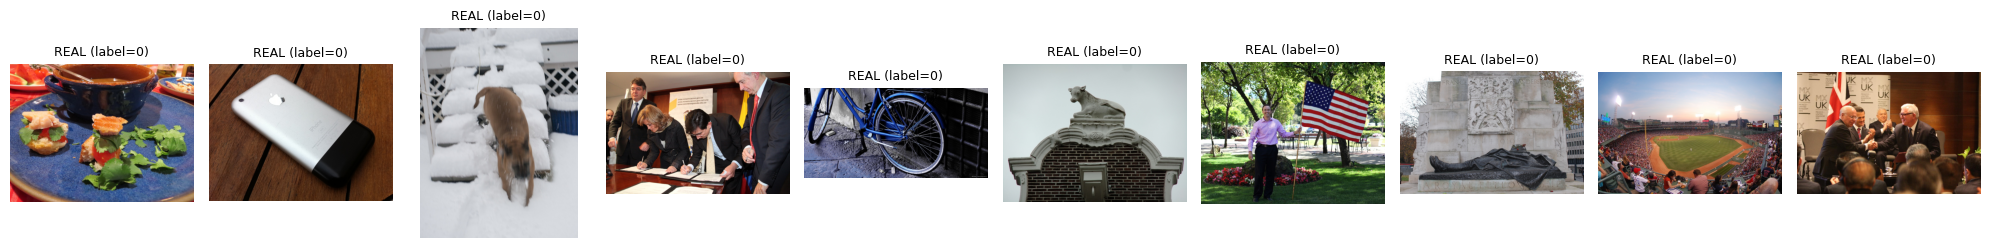

[(<PIL.Image.Image image mode=RGB size=1024x768>,
  filepath      /content/drive/MyDrive/techjam/sidset_subset/t...
  split                                                     train
  class_name                                                 REAL
  label                                                         0
  Name: 5930, dtype: object),
 (<PIL.Image.Image image mode=RGB size=1024x765>,
  filepath      /content/drive/MyDrive/techjam/sidset_subset/t...
  split                                                     train
  class_name                                                 REAL
  label                                                         0
  Name: 1758, dtype: object),
 (<PIL.Image.Image image mode=RGB size=768x1024>,
  filepath      /content/drive/MyDrive/techjam/sidset_subset/t...
  split                                                     train
  class_name                                                 REAL
  label                                                         

In [5]:
sample_train(df, n=10, label=0)

In [6]:
!pip install -q open_clip_torch
import torch, open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14-quickgelu", pretrained="openai"
)
model = model.to(device).eval()
for p in model.parameters():          # freezes the model: weights never change
    p.requires_grad_(False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

In [7]:
print(torch.cuda.is_available()) # check that colab is using GPU

True


## Part 2 — Robustness: training-time augmentation + a fixed evaluation grid

In [8]:
import os, io, json, math, random, hashlib
import numpy as np
import pandas as pd
import torch

# config for the training. CFG holds various parameters for the model

CFG = dict(
    n_train     = 14000,
    n_eval      = 1400,
    val_frac    = 0.15,     # held out of train; used ONLY for C-selection and thresholding
    k_aug_views = 3,        # augmented copies per training image (in addition to 1 clean copy)
    target_fpr  = 0.02,     # operating point: 11% of real images wrongly flagged as AI
    batch_size  = 256,
    num_workers = 2,
    seed        = 0,
    cache_dir   = "/content/feat_cache", # helps in case colab crashes
    crop_mode    = "texture", # options: "center" (CLIP default) or "texture" (TextureCrop)
    texture_topk = 5,        # for texture crop: number of times to average crop
)
os.makedirs(CFG["cache_dir"], exist_ok=True)

# seeds entire notebook so it is reproducible
def seed_everything(s: int) -> None:
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

seed_everything(CFG["seed"])

# print(CFG)

In [9]:
# Image augmentation
from PIL import Image, ImageFilter, ImageEnhance, ImageOps

def op_jpeg(img, quality):
    """Re-encode as JPEG at a given quality by saving to a buffer."""
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=int(quality))
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")

def op_blur(img, sigma):
    """Gaussian blur."""
    return img if sigma <= 0 else img.filter(ImageFilter.GaussianBlur(radius=sigma))

def op_resize(img, scale):
    """Downscale according to the scale, then upscale back to the original size."""
    w, h = img.size
    small_w, small_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    return img.resize((small_w, small_h), Image.BILINEAR).resize((w, h), Image.BILINEAR)

def op_noise(img, sigma, rng):
    """Adds Gaussian noise in [0, 1]."""
    a = np.asarray(img, dtype=np.float32) / 255.0
    a = np.clip(a + rng.normal(0.0, float(sigma), a.shape), 0.0, 1.0)
    return Image.fromarray((a * 255.0).astype(np.uint8))

def op_jitter(img, brightness, contrast, saturation):
    """Multiplicative brightness/contrast/saturation."""
    img = ImageEnhance.Brightness(img).enhance(float(brightness))
    img = ImageEnhance.Contrast(img).enhance(float(contrast))
    img = ImageEnhance.Color(img).enhance(float(saturation))
    return img

def op_crop(img, frac):
    """Centre crop to `frac` of each side."""
    w, h = img.size
    cropped_w, cropped_h = max(1, int(round(w * frac))), max(1, int(round(h * frac)))
    left, top = (w - cropped_w) // 2, (h - cropped_h) // 2
    return img.crop((left, top, left + cropped_w, top + cropped_h))

In [10]:
import numpy as np
# Evaluation bank based on the problem statement
JITTER = 0.20

EVAL_GRID = {
    "clean":        lambda im, rng: im,

    "jpeg_q90":     lambda im, rng: op_jpeg(im, 90),
    "jpeg_q70":     lambda im, rng: op_jpeg(im, 70),
    "jpeg_q50":     lambda im, rng: op_jpeg(im, 50),
    "jpeg_q30":     lambda im, rng: op_jpeg(im, 30),

    "blur_s0.5":    lambda im, rng: op_blur(im, 0.5),
    "blur_s1.0":    lambda im, rng: op_blur(im, 1.0),
    "blur_s2.0":    lambda im, rng: op_blur(im, 2.0),

    "resize_0.50x": lambda im, rng: op_resize(im, 0.50),
    "resize_0.25x": lambda im, rng: op_resize(im, 0.25),

    "noise_s0.02":  lambda im, rng: op_noise(im, 0.02, rng),
    "noise_s0.05":  lambda im, rng: op_noise(im, 0.05, rng),
    "noise_s0.10":  lambda im, rng: op_noise(im, 0.10, rng),

    "jitter_20pct": lambda im, rng: op_jitter(im, *(1.0 + rng.uniform(-JITTER, JITTER, 3))),
    "crop_80pct":   lambda im, rng: op_crop(im, 0.80),
}
CONDITIONS = list(EVAL_GRID)
DEGRADED   = [c for c in CONDITIONS if c != "clean"]


# Training bank: train in a continuous range around the eval range
# This is so the model should not memorise the exact eval criteria but can generalise
TRAIN_OPS = [
    lambda im, rng: op_jpeg(im, rng.integers(25, 96)),            # eval range is [30, 90]
    lambda im, rng: op_blur(im, rng.uniform(0.3, 2.3)),           # eval range is [0.5, 2.0]
    lambda im, rng: op_resize(im, rng.uniform(0.20, 0.50)),       # eval is 0.25, 0.50
    lambda im, rng: op_noise(im, rng.uniform(0.01, 0.12), rng),    # eval range is [0.02, 0.10]
    lambda im, rng: op_jitter(im, *(1.0 + rng.uniform(-0.23, 0.23, 3))),  # eval uses ±0.20
    lambda im, rng: op_crop(im, rng.uniform(0.70, 0.90)),         # eval uses 0.80
]

# P(apply operations). we choose to keep ~20% of views clean.
# Note: NO_OF_OPS supports multiple augmentations, but we are only augmenting once for this challenge.
NO_OF_OPS = np.array([0.20, 0.80])

def train_augment(img, rng):
    """Augments the training image `k` times, where `k` is based on probability
    from `NO_OF_OPS`.
    """
    k = int(rng.choice(len(NO_OF_OPS), p=NO_OF_OPS))
    if k == 0:
        return img
    order = rng.permutation(len(TRAIN_OPS))[:k]   # random subset AND random order
    for i in order:
        img = TRAIN_OPS[int(i)](img, rng)
    return img

print(f"{len(CONDITIONS)} eval conditions: {CONDITIONS}")

15 eval conditions: ['clean', 'jpeg_q90', 'jpeg_q70', 'jpeg_q50', 'jpeg_q30', 'blur_s0.5', 'blur_s1.0', 'blur_s2.0', 'resize_0.50x', 'resize_0.25x', 'noise_s0.02', 'noise_s0.05', 'noise_s0.10', 'jitter_20pct', 'crop_80pct']


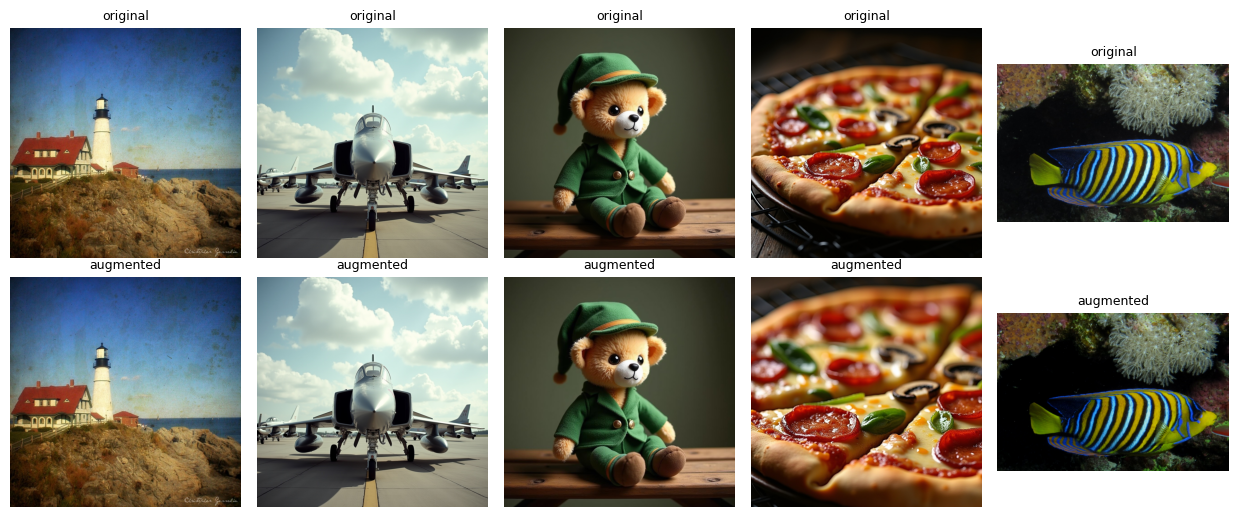

In [11]:
def check_augment(df, n=5, label=None, seed=0):
    """train_augment on `n` images just to confirm the images are being augmented.
    """
    pool = df[df["split"] == "train"]
    if label is not None:
        pool = pool[pool["label"] == label]
    picks = pool.sample(n=n, random_state=seed).reset_index(drop=True)

    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5.2), squeeze=False)
    for j, row in picks.iterrows():
        rng  = np.random.default_rng([seed, j]) # reproducible per image
        orig = ImageOps.exif_transpose(Image.open(row["filepath"])).convert("RGB")
        aug  = train_augment(orig.copy(), rng)

        axes[0][j].imshow(orig); axes[0][j].set_title("original", fontsize=9); axes[0][j].axis("off")
        axes[1][j].imshow(aug);  axes[1][j].set_title("augmented", fontsize=9); axes[1][j].axis("off")
    plt.tight_layout(); plt.show()


check_augment(df, n=5, seed=5)

In [12]:
# crop_mode:
#   "center"  -> CLIP's default resize -> center-crop -> normalize (original behaviour).
#   "texture" -> TextureCrop (Konstantinidou et al., WACV 2025): score 224x224 windows by
#                Global Histogram Entropy, keep the top-k richest. TRAIN uses one random
#                crop of the top-k (also acts as augmentation); TEST averages the k crop
#                embeddings. Because the probe is linear, averaging the k unit-norm crop
#                features means averaging their logits (the paper's aggregation) exactly.
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision.transforms import Compose, ToTensor
from tqdm.auto import tqdm
import cv2

# for texture crop: image is already 224x224, hence we skip CLIP's resize/center-crop
# and only normalize (the last transform).
tex_preprocess = Compose([ToTensor(), preprocess.transforms[-1]])


def texture_crops(pil_img, patch=224, stride=224, topk=10):
    """PIL RGB -> list of exactly `topk` texture-richest 224x224 PIL crops (Global Histogram
    Entropy). Pads images smaller than one window, and covers the right/bottom edge."""
    rgb = np.asarray(pil_img)                       # RGB, HxWx3, uint8
    h, w = rgb.shape[:2]
    if h < patch or w < patch:                      # pad tiny images up to one window
        pad_h, pad_w = max(patch, h), max(patch, w)
        canvas = np.zeros((pad_h, pad_w, 3), np.uint8); canvas[:h, :w] = rgb
        rgb = canvas; h, w = pad_h, pad_w

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    # get starting points of strides
    y_stride = list(range(0, h - patch + 1, stride)) or [0]
    x_stride = list(range(0, w - patch + 1, stride)) or [0]

    # make a new window to cover the ending pixels that might have been missed out
    if y_stride[-1] != h - patch: y_stride.append(h - patch)
    if x_stride[-1] != w - patch: x_stride.append(w - patch)

    scored = []
    for y in y_stride:
        for x in x_stride:
            g = gray[y:y+patch, x:x+patch]
            p = np.bincount(g.ravel(), minlength=256).astype(np.float64); p /= p.sum()
            p = p[p > 0]
            # Scores based on shannon entropy: https://arxiv.org/html/2407.15500
            scored.append((float(-(p * np.log2(p)).sum()), y, x))
    scored.sort(reverse=True)                        # richest first
    crops = [Image.fromarray(rgb[y:y+patch, x:x+patch]) for _, y, x in scored[:topk]]

    # pad out in case we do not have `topk` windows yet
    n0 = len(crops)
    while len(crops) < topk:
        crops.append(crops[len(crops) % n0])

    return crops

In [13]:
# turns an image into a feature matrix X and label y

class ViewDataset(Dataset):
    """mode: 'clean' | 'eval' (uses eval_key) | 'train_aug'. crop_mode: 'center' | 'texture'."""
    def __init__(self, frame, preprocess, mode="clean", view_id=0, eval_key=None, seed=0,
                 crop_mode="center", topk=10):
        self.frame = frame.reset_index(drop=True)
        self.preprocess, self.mode = preprocess, mode
        self.view_id, self.eval_key, self.seed = view_id, eval_key, seed
        self.crop_mode, self.topk = crop_mode, topk

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        # gets one item and augments it or applies the degredation
        row = self.frame.iloc[i]
        rng = np.random.default_rng([self.seed, self.view_id, i])
        img = Image.open(row["filepath"])
        img = ImageOps.exif_transpose(img).convert("RGB")
        if self.mode == "eval":
            img = EVAL_GRID[self.eval_key](img, rng)
        elif self.mode == "train_aug":
            img = train_augment(img, rng)

        # crop step
        if self.crop_mode == "texture":
            crops = texture_crops(img, topk=self.topk)
            if self.mode == "eval":
                # in eval mode, returns all k crops stacked into one tensor of shape [k, 3, 224, 224]
                return torch.stack([tex_preprocess(c) for c in crops]), int(row["label"])
            # in train/clean mode, one random crop
            j = int(rng.integers(0, len(crops)))
            return tex_preprocess(crops[j]), int(row["label"])
        return self.preprocess(img), int(row["label"])    # center-crop path


def _frame_tag(frame):
    """Short hash of the exact file list for the cache."""
    h = hashlib.sha1("\n".join(frame["filepath"].astype(str)).encode()).hexdigest()
    return h[:10]


@torch.no_grad()
def encode(frame, preprocess, mode="clean", view_id=0, eval_key=None,
           crop_mode=None, tag=None, desc=None):
    """Frozen-CLIP features for one view of `frame`.
    Output is cached to disk as .npz. crop_mode is folded into the cache key so
    'center' and 'texture' features never collide."""

    crop_mode = crop_mode or CFG["crop_mode"]
    # building cache
    tag = tag or f"{mode}_{eval_key or ''}_v{view_id}_{crop_mode}_{_frame_tag(frame)}"
    cache = os.path.join(CFG["cache_dir"], f"{tag}.npz")
    # load cache if exists
    if os.path.exists(cache):
        d = np.load(cache)
        return d["X"], d["y"]

    ds = ViewDataset(frame, preprocess, mode, view_id, eval_key, CFG["seed"],
                     crop_mode=crop_mode, topk=CFG["texture_topk"])
    loader = DataLoader(ds, batch_size=CFG["batch_size"], shuffle=False,
                        num_workers=CFG["num_workers"], pin_memory=True)
    feats, labels = [], []
    for x, y in tqdm(loader, desc=desc or tag, unit="batch", leave=False):
        if x.dim() == 5:
            # [B, k, C, H, W] if in eval texture mode, flatten to B*k
            B, k = x.shape[:2]
            x = x.view(B * k, *x.shape[2:]).to(device, non_blocking=True)
            if device == "cuda":
                # half precision to speed up model
                with torch.autocast("cuda", dtype=torch.float16):
                    f = model.encode_image(x)
            else:
                f = model.encode_image(x)
            # l2-normalizes each unit vector (scales to unit length)
            f = F.normalize(f.float(), dim=-1).view(B, k, -1).mean(1)  # unflattens to regroup the crops
            # move off gpu
            feats.append(f.cpu())
        else:
            x = x.to(device, non_blocking=True)
            if device == "cuda":
                with torch.autocast("cuda", dtype=torch.float16):
                    f = model.encode_image(x)
            else:
                f = model.encode_image(x)
            feats.append(F.normalize(f.float(), dim=-1).cpu())
        labels.append(y)

    # concatenates into one tensor and returns output
    X = torch.cat(feats).numpy().astype(np.float32)
    y = torch.cat(labels).numpy().astype(np.int64)
    np.savez_compressed(cache, X=X, y=y)
    return X, y

In [14]:
# Splits the validation set out from the training set, and balances test set by class
rs = CFG["seed"]

train_pool = (df[df["split"] == "train"]
              .sample(n=min(CFG["n_train"], (df["split"] == "train").sum()), random_state=rs)
              .reset_index(drop=True))

# take out validation set first
val_frame = train_pool.sample(frac=CFG["val_frac"], random_state=rs)
fit_frame = train_pool.drop(val_frame.index).reset_index(drop=True)
val_frame = val_frame.reset_index(drop=True)

test_all   = df[df["split"] == "test"]

# makes the test set class balanced
eval_frame = (pd.concat([test_all[test_all["label"] == c].sample(n=CFG["n_eval"] // 2, random_state=rs)
                         for c in (0, 1)])
                .sample(frac=1.0, random_state=rs) # shuffles set
                .reset_index(drop=True))

# check balance
print(f"fit  : {len(fit_frame):>6}  ({fit_frame.label.mean():.1%} AI)")
print(f"val  : {len(val_frame):>6}  ({val_frame.label.mean():.1%} AI)")
print(f"eval : {len(eval_frame):>6}  ({eval_frame.label.mean():.1%} AI)")

fit  :  11900  (50.0% AI)
val  :   2100  (50.4% AI)
eval :   1400  (50.0% AI)


In [15]:
# Feature extraction, with cache in case the cell crashes

# extracts features for clean images, builds clean probe
X_fit_clean, y_fit_clean = encode(fit_frame, preprocess, "clean", desc="fit / clean")

# augments views and extracts features
aug_X, aug_y = [], []
for v in range(1, CFG["k_aug_views"] + 1):
    Xv, yv = encode(fit_frame, preprocess, "train_aug", view_id=v, desc=f"fit / aug view {v}")
    aug_X.append(Xv); aug_y.append(yv)

# builds the robust probe
X_fit_robust = np.concatenate([X_fit_clean] + aug_X)
y_fit_robust = np.concatenate([y_fit_clean] + aug_y)

X_val_clean, y_val_clean = encode(val_frame, preprocess, "clean", desc="val / clean")
X_val_aug,   y_val_aug   = encode(val_frame, preprocess, "train_aug", view_id=99, desc="val / aug")

# calibration for texture-cropping: k-crop average
if CFG["crop_mode"] == "texture":
    X_val_calib, y_val_calib = encode(val_frame, preprocess, "eval", eval_key="clean",
                                      desc="val / calib (agg)")
else:
    X_val_calib, y_val_calib = X_val_clean, y_val_clean

print(f"baseline train matrix : {X_fit_clean.shape}")
print(f"robust   train matrix : {X_fit_robust.shape}")

fit / clean:   0%|          | 0/47 [00:00<?, ?batch/s]

fit / aug view 1:   0%|          | 0/47 [00:00<?, ?batch/s]

fit / aug view 2:   0%|          | 0/47 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

fit / aug view 3:   0%|          | 0/47 [00:00<?, ?batch/s]

...

val / aug:   0%|          | 0/9 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


val / calib (agg):   0%|          | 0/9 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

baseline train matrix : (11900, 768)
robust   train matrix : (47600, 768)


In [16]:
# Fits two logistic regression probes: One trained on clean data and one trained on robust data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

C_GRID = [0.1, 1.0, 10.0]

def fit_probe(X, y, name):
    best, best_auc, best_C = None, -np.inf, C_GRID[0]
    for C in C_GRID:
        clf = LogisticRegression(max_iter=2000, C=C, class_weight="balanced")
        clf.fit(X, y)
        auc = roc_auc_score(y_val_aug, clf.predict_proba(X_val_aug)[:, 1])
        print(f"  {name:<9} C={C:<5} augmented-val AUC = {auc:.4f}")
        if auc > best_auc:
            best, best_auc, best_C = clf, auc, C
    print(f"  -> {name}: selected C={best_C} (augmented-val AUC {best_auc:.4f})\n")
    return best

probes = {
    "baseline": fit_probe(X_fit_clean,  y_fit_clean,  "baseline"),
    "robust":   fit_probe(X_fit_robust, y_fit_robust, "robust"),
}

  baseline  C=0.1   augmented-val AUC = 0.9742
  baseline  C=1.0   augmented-val AUC = 0.9820
  baseline  C=10.0  augmented-val AUC = 0.9853
  -> baseline: selected C=10.0 (augmented-val AUC 0.9853)

  robust    C=0.1   augmented-val AUC = 0.9853
  robust    C=1.0   augmented-val AUC = 0.9918
  robust    C=10.0  augmented-val AUC = 0.9935
  -> robust: selected C=10.0 (augmented-val AUC 0.9935)



In [17]:
# thresholding to aim to achieve some false positive rate
def threshold_at_fpr(clf, X, y, target_fpr):
    """Largest score below which at most `target_fpr` of REAL images fall."""
    s_real = clf.predict_proba(X[y == 0])[:, 1]
    return float(np.quantile(s_real, 1.0 - target_fpr))

THRESH = {name: threshold_at_fpr(clf, X_val_calib, y_val_calib, CFG["target_fpr"])
          for name, clf in probes.items()}

for name, t in THRESH.items():
    print(f"{name:<9} threshold = {t:.4f}   (targets {CFG['target_fpr']:.0%} FPR on clean real images)")

baseline  threshold = 0.3579   (targets 2% FPR on clean real images)
robust    threshold = 0.3042   (targets 2% FPR on clean real images)


In [18]:
# ============================================================================
# Simple evaluation: clean vs. random augmentation, for both probes.
#
# Replaces the 15-condition robustness grid with a compact two-row check. Metrics:
#   accuracy - at the fixed (clean-calibrated) threshold
#   AP       - average precision = area under the precision-recall curve ("PR")
#   AUC      - area under the ROC curve
# ============================================================================
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

# "random_aug" reuses the training augmentation bank (a random 0-2 chained ops per image),
# routed through the eval path so it gets the SAME crop handling as clean (k-crop average
# in texture mode, single center crop otherwise).
EVAL_GRID.setdefault("random_aug", lambda im, rng: train_augment(im, rng))

TEST_CONDITIONS = ["clean", "random_aug"]

rows = []
for cond in TEST_CONDITIONS:
    Xc, yc = encode(eval_frame, preprocess, "eval", eval_key=cond,
                    crop_mode=CFG["crop_mode"], desc=f"test / {cond}")
    for name, clf in probes.items():
        prob = clf.predict_proba(Xc)[:, 1]
        pred = (prob >= THRESH[name]).astype(int)
        rows.append(dict(condition=cond, probe=name,
                         accuracy=accuracy_score(yc, pred),
                         AP=average_precision_score(yc, prob),   # PR: area under precision-recall curve
                         AUC=roc_auc_score(yc, prob),
                         n=len(yc)))

results = pd.DataFrame(rows)[["condition", "probe", "accuracy", "AP", "AUC", "n"]].round(4)
print(results.to_string(index=False))

results.to_csv("simple_results.csv", index=False)
with open("simple_results.md", "w") as f:
    f.write("# Simple evaluation: clean vs. random augmentation\n\n")
    f.write(f"CLIP ViT-L/14 frozen backbone + linear probe. n = {len(eval_frame)} eval images "
            f"(class-balanced). accuracy at the fixed {CFG['target_fpr']:.0%}-FPR threshold; "
            f"AP = area under the precision-recall curve; AUC = ROC AUC.\n\n")
    f.write(results.to_markdown(index=False))
print("\nsaved simple_results.csv and simple_results.md")

test / clean:   0%|          | 0/6 [00:00<?, ?batch/s]

test / random_aug:   0%|          | 0/6 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ea8ab27c40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

 condition    probe  accuracy     AP    AUC    n
     clean baseline    0.9900 0.9995 0.9994 1400
     clean   robust    0.9900 0.9994 0.9993 1400
random_aug baseline    0.9650 0.9955 0.9954 1400
random_aug   robust    0.9764 0.9980 0.9979 1400

saved simple_results.csv and simple_results.md


## Part 3: Shipping the deliverables

In [19]:
import shutil
for f in ["simple_results.csv", "simple_results.md"]:
    print(f, "is", os.path.getsize(f), "bytes")

try:                                    # optional: keep a copy on Drive
    from google.colab import files
    files.download("simple_results.md")
    files.download("simple_results.csv")
except Exception as e:
    print("(skipping browser download:", e, ")")

simple_results.csv is 198 bytes
simple_results.md is 626 bytes
(skipping browser download: Cannot find file: robustness_table.md )


In [20]:
# Saving the trained detector
import joblib, os, time

SAVE_DIR = "/content/drive/MyDrive/techjam"
os.makedirs(SAVE_DIR, exist_ok=True)

BUNDLE = {
    "clip_model":      "ViT-L-14-quickgelu",
    "clip_pretrained": "openai",
    "embed_dim":       768,
    "normalize":       "l2",
    "crop_mode":       CFG["crop_mode"],         # "center" or "texture" -- inference reads this
    "texture_topk":    CFG["texture_topk"],      # k crops averaged, when texture
    "probes":          probes,                   # {"baseline": clf, "robust": clf}
    "thresholds":      THRESH,                   # per-probe operating point (likely to be inaccurate with new data)
    "target_fpr":      CFG["target_fpr"],
    "label_meaning":   {0: "real", 1: "ai_generated"},
    "trained_on":      "SID_Set subset",
    "sklearn_version": __import__("sklearn").__version__,
}
BUNDLE_PATH = os.path.join(SAVE_DIR, f"standard_{time.strftime('%Y%m%d-%H%M')}.joblib")
joblib.dump(BUNDLE, BUNDLE_PATH)
print("saved", BUNDLE_PATH, f"({os.path.getsize(BUNDLE_PATH)/1024:.1f} KB)  crop_mode={CFG['crop_mode']}")

saved /content/drive/MyDrive/techjam/standard_20260831-1323.joblib (13.5 KB)  crop_mode=texture
